In [1]:
from datetime import timedelta, datetime
import pprint
import time

import ee
from IPython.display import Image, display
import ipyplot
import matplotlib.pyplot as plt
import numpy as np
import openet.core

ee.Initialize()

In [2]:
monthly_coll = ee.ImageCollection('projects/openet/assets/ensemble/conus/gridmet/monthly/v2_0')
band_name = 'et_ensemble_mad'

years = list(range(2000, 2026))

region = ee.Geometry.BBox(-125.5, 25, -85.5, 50)
#region = ee.Geometry.BBox(-125.0, 25, -86.0, 50)

image_size = 768

et_palette = ['DEC29B', 'E6CDA1', 'EDD9A6', 'F5E4A9', 'FFF4AD', 'C3E683', '6BCC5C', '3BB369', '20998F', '1C8691', '16678A', '114982', '0B2C7A']
viridis = ['440154', '433982', '30678D', '218F8B', '36B677', '8ED542', 'FDE725']
# et_vis = {min: 0, max: 150, palette: et_palette}

land_mask = ee.Image('projects/openet/assets/features/water_mask').Not()
# Apply the NLCD/NALCMS water mask (anywhere it is water, set the ocean mask 
land_mask = land_mask.where(ee.Image("USGS/NLCD_RELEASES/2020_REL/NALCMS").unmask(18).eq(18), 0)
# land_mask = land_mask.And(ee.Image("USGS/NLCD_RELEASES/2020_REL/NALCMS").unmask(18).neq(18))
# # land_mask = ee.Image('projects/openet/assets/meteorology/conus404/ancillary/land_mask')


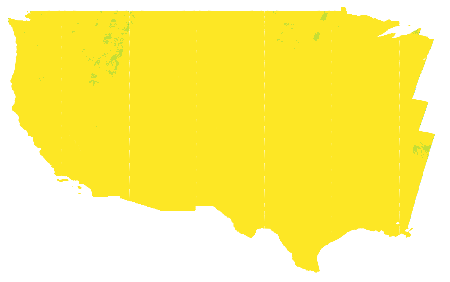

In [3]:
start_date = '2024-01-01'
end_date = '2025-01-01'

image_url = (
    monthly_coll.filterDate(start_date, end_date).select([band_name]).count()
    .visualize(min=0, max=12, palette=viridis)
    .getThumbURL({'region': region, 'dimensions': 450})
)
Image(image_url, embed=True, format='png')  

In [4]:
for year in years:
    print(year)
    image_url = (
        monthly_coll.filterDate(f'{year}-01-01', f'{year+1}-01-01').select([band_name]).count()
        .visualize(min=0, max=12, palette=viridis)
        .getThumbURL({'region': region, 'dimensions': image_size})
    )
    ipyplot.plot_images([image_url], img_width=image_size, show_url=False)
    time.sleep(1)

2000


2001


2002


2003


2004


...

2021


2022


2023


2024


2025


In [5]:
# Map.addLayer(ensemble_conus_coll.select(['et_ensemble_sam']).sum().divide(months), et_vis, 'SAM CONUS ET', false);
# Map.addLayer(ensemble_conus_coll.select(['et_ensemble_mad']).sum().divide(months), et_vis, 'MAD Mean CONUS ET', true);
# //Map.addLayer(ensemble_conus_coll.select(['et_ensemble_mad_index']), {min:0, max:256}, 'MAD Index CONUS ET', false);
# Map.addLayer(ensemble_conus_coll.select(['et_ensemble_mad']).count(), {min:0, max:12, palette: viridis}, 'Month Count CONUS ET', true);
# Map.addLayer(ensemble_conus_coll.select(['et_ensemble_mad_count']).mean(), {min:0, max:6, palette: viridis}, 'Model Count CONUS ET', true);
